# 04 — Baseline models (Phase 4)

Lower-bound reference models for STM08 water-level forecasting: **persistence**, **ridge** (linear) and **random forest**.

Each model is fit on the chronological train split (2014–2020) and evaluated on train / validation / test for the three horizons **t+1h, t+6h, t+24h**.

> **Caveat** — the test split (2022-07 → 2026-07) contains the *extension* period
> (2025-07 onwards) whose STM08 datum is still under review (3–5 m readings vs a
> 2.83 m historical maximum). Test metrics are therefore reported both on the full
> test window and on the *validated* window (pre-2025-07-22) to isolate that effect.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from scripts.evaluation.baselines import (
    predictor_cols, persistence_predictions, fit_ridge, fit_random_forest,
)
from scripts.evaluation import metrics as M

PROCESSED = Path("data/processed")
RESULTS = Path("results/metrics")
RESULTS.mkdir(parents=True, exist_ok=True)

HORIZONS = [1, 6, 24]
SPLITS = ["train", "validation", "test"]
THRESHOLDS = [0.5, 1.0]
VALIDATED_TEST_END = "2025-07-22"   # end of the validated (pre-extension) record

df = pd.read_parquet(PROCESSED / "training_table.parquet")
events = pd.read_csv(PROCESSED / "events.csv")
print(f"Training table: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Predictor columns: {len(predictor_cols(df))}")

Training table: 614,201 rows x 289 cols
Predictor columns: 255


In [2]:
def evaluate_split(obs, sim):
    row = M.evaluate(obs, sim)
    pk = M.peak_error(obs, sim)
    row["peak_mag_err_m"] = pk["peak_mag_err_m"]
    row["peak_time_err_h"] = pk["peak_time_err_h"]
    for t in THRESHOLDS:
        tm = M.threshold_metrics(obs, sim, t)
        row[f"pod@{t}m"] = tm["pod"]; row[f"far@{t}m"] = tm["far"]; row[f"csi@{t}m"] = tm["csi"]
    return row

def run_model(model_name, horizon):
    if model_name == "persistence":
        pred = persistence_predictions(df)
        return {s: pred.loc[df["split"] == s] for s in SPLITS}
    if model_name == "ridge":
        return fit_ridge(df, horizon)
    if model_name == "random_forest":
        return fit_random_forest(df, horizon)
    raise ValueError(model_name)

## Run the three baselines and build the summary table

In [3]:
summary_rows = []
for model in ["persistence", "ridge", "random_forest"]:
    for h in HORIZONS:
        preds = run_model(model, h)
        for split in SPLITS:
            sub = df[df["split"] == split]
            r = evaluate_split(sub[f"TARGET_t+{h}h"], preds[split])
            summary_rows.append({"model": model, "horizon_h": h, "split": split, **r})

summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULTS / "baselines_summary.csv", index=False)
piv = summary.pivot_table(index=["model", "horizon_h"], columns="split", values="nse")
print(piv.round(3))

split                     test  train  validation
model         horizon_h                          
persistence   1          0.988  0.983       0.994
              6          0.911  0.918       0.971
              24         0.563  0.710       0.847
random_forest 1          0.980  0.999       0.985
              6          0.834  0.990       0.953
              24         0.336  0.984       0.810
ridge         1          0.987  0.994       0.981
              6          0.875  0.946       0.933
              24         0.472  0.808       0.560


## Isolate the extension (datum-shift) effect on the test split

The test split spans 2022-07 → 2026-07.  The last ~12 % (2026) is the
datum-shifted extension.  Re-evaluate test NSE on the *validated* window only.

In [4]:
test = df[df["split"] == "test"]
rows = []
for model in ["persistence", "ridge", "random_forest"]:
    for h in HORIZONS:
        preds = run_model(model, h)["test"]
        obs = test[f"TARGET_t+{h}h"]
        full = M.evaluate(obs, preds)["nse"]
        mask = test.index < VALIDATED_TEST_END
        valid = M.evaluate(obs[mask], preds[mask])["nse"]
        ext = M.evaluate(obs[~mask], preds[~mask])["nse"]
        rows.append({"model": model, "horizon_h": h, "test_all": full, "test_validated": valid, "test_extension": ext})

split_nse = pd.DataFrame(rows)
print(split_nse.round(3))
split_nse.to_csv(RESULTS / "baselines_test_split.csv", index=False)

           model  horizon_h  test_all  test_validated  test_extension
0    persistence          1     0.988           0.990           0.979
1    persistence          6     0.911           0.915           0.890
2    persistence         24     0.563           0.536           0.708
3          ridge          1     0.987           0.989           0.976
4          ridge          6     0.875           0.871           0.893
5          ridge         24     0.472           0.427           0.713
6  random_forest          1     0.980           0.980           0.975
7  random_forest          6     0.834           0.834           0.833
8  random_forest         24     0.336           0.354           0.232


## Per-event evaluation (test-split flood events)

In [5]:
per_event = []
for model in ["persistence", "ridge", "random_forest"]:
    for h in HORIZONS:
        preds = run_model(model, h)["test"]
        obs = test[f"TARGET_t+{h}h"]
        ev_test = events[events["split"] == "test"]
        pe = M.per_event_metrics(obs, preds, ev_test)
        pe["model"] = model; pe["horizon_h"] = h
        per_event.append(pe)
pe_all = pd.concat(per_event, ignore_index=True)
pe_all.to_csv(RESULTS / "baselines_per_event.csv", index=False)
med = pe_all.groupby(["model", "horizon_h"])["nse"].median().unstack()
print("median per-event NSE:")
print(med.round(3))

median per-event NSE:
horizon_h         1      6      24
model                             
persistence    0.525 -1.274  0.204
random_forest  0.255 -5.683 -3.195
ridge          0.524 -1.897 -2.139


## Summary figure: test NSE by horizon (validated window)

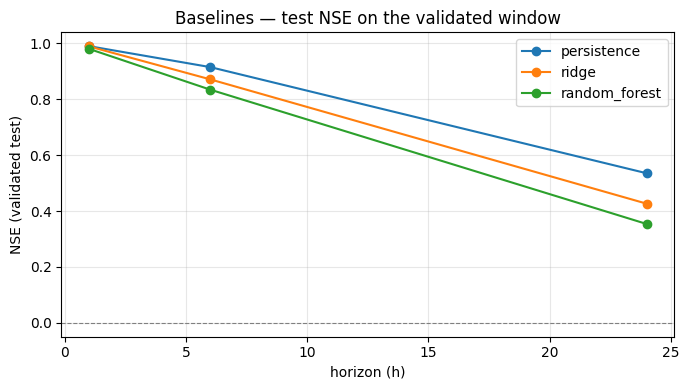

Figure saved to results\metrics\baselines_nse.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for model in ["persistence", "ridge", "random_forest"]:
    d = split_nse[split_nse["model"] == model]
    ax.plot(d["horizon_h"], d["test_validated"], "o-", label=model)
ax.axhline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("horizon (h)"); ax.set_ylabel("NSE (validated test)")
ax.set_title("Baselines — test NSE on the validated window")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(RESULTS / "baselines_nse.png", dpi=150)
plt.show()
print("Figure saved to", RESULTS / "baselines_nse.png")